In [11]:
import pandas as pd
import numpy as np
import glob
import os
from IPython.display import display


# LOAD ALL BID FILES

bid_files = glob.glob(r"Raw Data aFRR(10-05)\Anonymous bid\*.xlsx")

print("Bid files found:", len(bid_files))
print(bid_files[:5])

bid_list = []
for f in bid_files:
    if os.path.isfile(f):
        df = pd.read_excel(f)
        bid_list.append(df)

bids = pd.concat(bid_list, ignore_index=True)  
print("Total bid rows:", len(bids))
display(bids.head())


# ===============================
# LOAD ALL ACTIVATION FILES


activation_files = glob.glob(r"Raw Data aFRR(10-05)\Activate AFRR Volume\*.csv")

print("Activation files found:", len(activation_files))
print(activation_files[:5])

act_list = []
for f in activation_files:
    if os.path.isfile(f):
        df = pd.read_csv(f, sep=";")
        act_list.append(df)

activation = pd.concat(act_list, ignore_index=True)

print("Total activation rows:", len(activation))
display(activation.head())

Bid files found: 1
['Raw Data aFRR(10-05)\\Anonymous bid\\RESULT_LIST_ANONYM_ENERGY_MARKET_aFRR_2025-10-05_2025-10-05.xlsx']
Total bid rows: 125764


,DELIVERY_DATE,TYPE_OF_RESERVES,PRODUCT,ENERGY_PRICE_[EUR/MWh],ENERGY_PRICE_PAYMENT_DIRECTION,OFFERED_CAPACITY_[MW],ALLOCATED_CAPACITY_[MW],COUNTRY,NOTE
0,2025-10-05,aFRR,NEG_001,107.81,GRID_TO_PROVIDER,5,5,DE,NaN
1,2025-10-05,aFRR,NEG_001,107.81,GRID_TO_PROVIDER,5,5,DE,NaN
2,2025-10-05,aFRR,NEG_001,107.82,GRID_TO_PROVIDER,5,5,DE,NaN
3,2025-10-05,aFRR,NEG_001,107.82,GRID_TO_PROVIDER,5,5,DE,NaN
4,2025-10-05,aFRR,NEG_001,107.83,GRID_TO_PROVIDER,5,5,DE,NaN


Activation files found: 1
['Raw Data aFRR(10-05)\\Activate AFRR Volume\\Aktivierte aFRR betrieblich [2026-03-21 16-42-29].csv']
Total activation rows: 96


,Datum,von,bis,Einheit,Deutschland pos,Deutschland neg,50Hertz pos,50Hertz neg,Amprion pos,Amprion neg,TenneT TSO pos,TenneT TSO neg,TransnetBW pos,TransnetBW neg,MOL-Abweichung
0,2025-10-05,00:00,00:15,MW,1.024,177.914,0.000,68.208,0.0,17.575,0.451,31.211,0.573,60.920,0
1,2025-10-05,00:15,00:30,MW,0.576,320.893,0.009,100.703,0.0,35.260,0.149,57.231,0.418,127.699,0
2,2025-10-05,00:30,00:45,MW,0.853,219.026,0.252,73.029,0.0,27.105,0.218,39.486,0.383,79.406,0
3,2025-10-05,00:45,01:00,MW,0.071,613.486,0.000,239.159,0.0,56.582,0.071,107.798,0.000,209.947,0
4,2025-10-05,01:00,01:15,MW,0.252,290.494,0.000,115.363,0.0,33.558,0.252,47.884,0.000,93.689,0


In [12]:
# 1. RENAME COLUMNS TO SIMPLE NAMES
# ADAPT THESE TO YOUR REAL COLUMN NAMES

# ---- bids dataset ----
bids = bids.rename(columns={
    "PRODUCT": "product",
    "DELIVERY_TIME": "period",
    "ENERGY_PRICE_[EUR/MWh]": "price",
    "OFFERED_CAPACITY_[MW]": "OFFERED_CAPACITY_[MW]",
    "ALLOCATED_CAPACITY_[MW]": "ALLOCATED_CAPACITY_[MW]"
})

# if quantity is not allocated but offered, use this instead:
if "ALLOCATED_CAPACITY_[MW]" not in bids.columns and "OFFERED_CAPACITY_[MW]" in bids.columns:
    bids["ALLOCATED_CAPACITY_[MW]"] = bids["OFFERED_CAPACITY_[MW]"]

# ---- activation dataset ----
activation = activation.rename(columns={
    "von": "Start", 
    "bis": "End",
    "Deutschland neg": "Activated MW neg",
    "Datum": "Date"
})

# display renamed columns
print("BIDS COLUMNS:")
print(bids.columns.tolist())
print("\nACTIVATION COLUMNS:")
print(activation.columns.tolist())



BIDS COLUMNS:
['DELIVERY_DATE', 'TYPE_OF_RESERVES', 'product', 'price', 'ENERGY_PRICE_PAYMENT_DIRECTION', 'OFFERED_CAPACITY_[MW]', 'ALLOCATED_CAPACITY_[MW]', 'COUNTRY', 'NOTE']

ACTIVATION COLUMNS:
['Date', 'Start', 'End', 'Einheit', 'Deutschland pos', 'Activated MW neg', '50Hertz pos', '50Hertz neg', 'Amprion pos', 'Amprion neg', 'TenneT TSO pos', 'TenneT TSO neg', 'TransnetBW pos', 'TransnetBW neg', 'MOL-Abweichung']


In [13]:
# 2. FILTER TO NEG ONLY
bids_neg = bids[bids["product"].astype(str).str.contains("NEG", case=False, na=False)].copy()

display(bids_neg.head())



,DELIVERY_DATE,TYPE_OF_RESERVES,product,price,ENERGY_PRICE_PAYMENT_DIRECTION,OFFERED_CAPACITY_[MW],ALLOCATED_CAPACITY_[MW],COUNTRY,NOTE
0,2025-10-05,aFRR,NEG_001,107.81,GRID_TO_PROVIDER,5,5,DE,NaN
1,2025-10-05,aFRR,NEG_001,107.81,GRID_TO_PROVIDER,5,5,DE,NaN
2,2025-10-05,aFRR,NEG_001,107.82,GRID_TO_PROVIDER,5,5,DE,NaN
3,2025-10-05,aFRR,NEG_001,107.82,GRID_TO_PROVIDER,5,5,DE,NaN
4,2025-10-05,aFRR,NEG_001,107.83,GRID_TO_PROVIDER,5,5,DE,NaN


In [16]:
import pandas as pd
import datetime as dt

activation = activation.copy()

activation["Date"] = pd.to_datetime(activation["Date"], errors="coerce").dt.normalize()

def to_timedelta_col(s):
    def convert(x):
        if pd.isna(x):
            return pd.NaT
        if isinstance(x, dt.time):
            return pd.to_timedelta(x.strftime("%H:%M:%S"))
        if isinstance(x, dt.datetime):
            return pd.to_timedelta(x.strftime("%H:%M:%S"))

        x = str(x).strip()
        if x in ["", "NaT", "nan", "None"]:
            return pd.NaT

        return pd.to_timedelta(x, errors="coerce")

    return s.map(convert)

# activation["start_td"] = to_timedelta_col(activation["Start"])
# activation["end_td"] = to_timedelta_col(activation["End"])
# If Start/End are strings like "12:15" or "12:15:00"
activation["start_td"] = pd.to_timedelta(activation["Start"] + ":00")
activation["end_td"]   = pd.to_timedelta(activation["End"] + ":00")

# Now you can safely add to Date
activation["start_dt"] = activation["Date"] + activation["start_td"]
activation["end_dt"]   = activation["Date"] + activation["end_td"]

activation["start_dt"] = activation["Date"] + activation["start_td"]
activation["end_dt"] = activation["Date"] + activation["end_td"]

activation["start_time"] = activation["start_dt"].dt.time
activation["end_time"] = activation["end_dt"].dt.time

activation["period"] = (
    ((activation["start_dt"].dt.hour * 60 + activation["start_dt"].dt.minute) // 15) + 1
).astype("Int64")

activation_neg = activation[[
    "Date",
    "start_time",
    "end_time",
    "period",
    "Activated MW neg"
]].copy()

print(activation_neg.head(10))
print("Missing periods:", activation_neg["period"].isna().sum())
print("Min period:", activation_neg["period"].min())
print("Max period:", activation_neg["period"].max())

        Date start_time  end_time  period  Activated MW neg
0 2025-10-05   00:00:00  00:15:00       1           177.914
1 2025-10-05   00:15:00  00:30:00       2           320.893
2 2025-10-05   00:30:00  00:45:00       3           219.026
3 2025-10-05   00:45:00  01:00:00       4           613.486
4 2025-10-05   01:00:00  01:15:00       5           290.494
5 2025-10-05   01:15:00  01:30:00       6            39.582
6 2025-10-05   01:30:00  01:45:00       7            48.284
7 2025-10-05   01:45:00  02:00:00       8           196.190
8 2025-10-05   02:00:00  02:15:00       9           103.254
9 2025-10-05   02:15:00  02:30:00      10            14.536
Missing periods: 0
Min period: 1
Max period: 96


In [18]:
# 4. IF BID PERIOD IS EMBEDDED IN PRODUCT NAME, EXTRACT IT
#    Example: NEG_001 -> 1


if bids_neg["product"].astype(str).str.contains("NEG_", case=False, na=False).any():
    bids_neg["period"] = (
        bids_neg["product"]
        .astype(str)
        .str.extract(r"NEG[_-]?(\d+)", expand=False)
        .astype(float)
    )

bids_neg["period"] = bids_neg["period"].astype(int)

display(bids_neg[["product", "period", "price", "OFFERED_CAPACITY_[MW]"]].head())


,product,period,price,OFFERED_CAPACITY_[MW]
0,NEG_001,1,107.81,5
1,NEG_001,1,107.81,5
2,NEG_001,1,107.82,5
3,NEG_001,1,107.82,5
4,NEG_001,1,107.83,5


# Step 2 : Build the Merit Order List (MOL)

In [19]:
def build_mol(bids_interval: pd.DataFrame) -> pd.DataFrame:
    mol = bids_interval.sort_values("price").copy()
    mol["cum_capacity"] = mol["OFFERED_CAPACITY_[MW]"].cumsum()
    return mol




# Step 3 — Determine marginal activation price  Pmax⁡,t FOR EACH 15-MINUTE INTERVAL
# Pmax⁡,t =  min{p: Ψ(p) ≥ St}

	​


In [20]:

# STEP 3 — Determine marginal activation price pmax_t for each 15-min interval
# pmax_t = min{p : cumulative_capacity(p) >= activated_volume_t}

def get_pmax(mol: pd.DataFrame, activated_volume: float):

    if pd.isna(activated_volume) or activated_volume <= 0:
        return np.nan

    eligible = mol[mol["cum_capacity"] >= activated_volume]

    if eligible.empty:
        return np.nan

    return eligible.iloc[0]["price"]


pmax_list = []

for _, act_row in activation_neg.dropna(subset=["period"]).iterrows():

    period = int(act_row["period"])
    act_date = act_row["Date"]

    bids_t = bids_neg[
        (bids_neg["DELIVERY_DATE"] == act_date) &
        (bids_neg["period"] == period)
    ].copy()

    if bids_t.empty:
        continue

    activated_volume = pd.to_numeric(act_row["Activated MW neg"], errors="coerce")

    mol_t = build_mol(bids_t)

    pmax = get_pmax(mol_t, activated_volume)

    pmax_list.append({
        "Date": act_date,
        "period": period,
        "start_time": act_row["start_time"],
        "end_time": act_row["end_time"],
        "Activated_MW_neg": activated_volume,
        "pmax": pmax
    })


pmax_df = pd.DataFrame(pmax_list).sort_values(["Date", "period"]).reset_index(drop=True)

print("\nPMAX TABLE")
display(pmax_df.head(20))

print(f"\nRows in pmax_df: {len(pmax_df)}")
print(f"Unique dates: {pmax_df['Date'].nunique()}")


PMAX TABLE


,Date,period,start_time,end_time,Activated_MW_neg,pmax
0,2025-10-05,1,00:00:00,00:15:00,177.914,16.62
1,2025-10-05,2,00:15:00,00:30:00,320.893,29.70
2,2025-10-05,3,00:30:00,00:45:00,219.026,9.89
3,2025-10-05,4,00:45:00,01:00:00,613.486,100.14
4,2025-10-05,5,01:00:00,01:15:00,290.494,26.56
5,2025-10-05,6,01:15:00,01:30:00,39.582,4.40
6,2025-10-05,7,01:30:00,01:45:00,48.284,4.86
7,2025-10-05,8,01:45:00,02:00:00,196.190,25.00
8,2025-10-05,9,02:00:00,02:15:00,103.254,7.12
9,2025-10-05,10,02:15:00,02:30:00,14.536,0.00



Rows in pmax_df: 96
Unique dates: 1


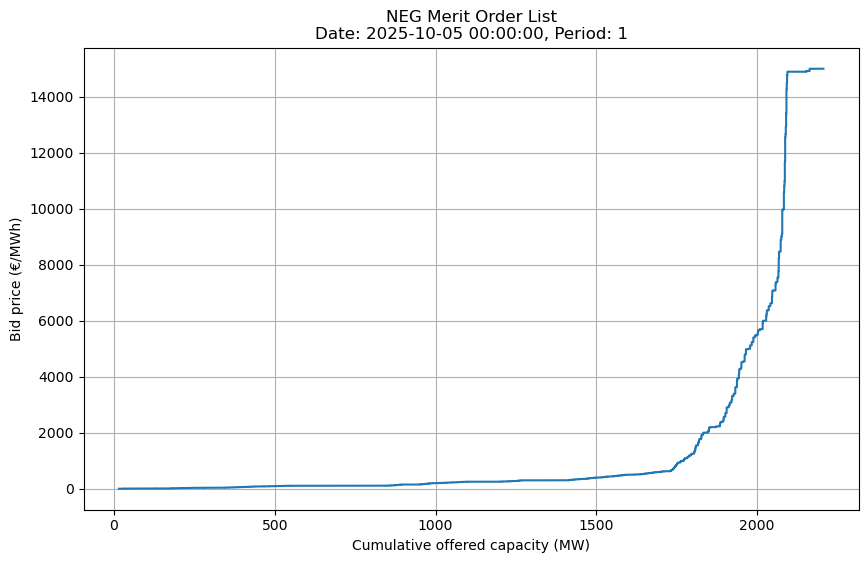

In [21]:

# MOl Supply curve
import matplotlib.pyplot as plt

# choose an example interval
plot_date = bids_neg["DELIVERY_DATE"].iloc[0]
plot_period = int(bids_neg["period"].iloc[0])

# build merit order for that interval
mol_plot = build_mol(
    bids_neg[
        (bids_neg["DELIVERY_DATE"] == plot_date) &
        (bids_neg["period"] == plot_period)
    ]
)

plt.figure(figsize=(10,6))

plt.step(
    mol_plot["cum_capacity"],
    mol_plot["price"],
    where="post"
)

plt.xlabel("Cumulative offered capacity (MW)")
plt.ylabel("Bid price (€/MWh)")
plt.title(f"NEG Merit Order List\nDate: {plot_date}, Period: {plot_period}")

plt.grid(True)

plt.show()

# Step 4:compute activation probability for a bid price p (this is the probability function) in a random 15-min interval of the day.
 A  bid is activated in an interval  if its energy price p  ≤ the highest activated price(Pmax).
 
P ̂(activated∣p)=   1/N ∑_(t=1 )^N▒〖 1{p〗≤Pmax,t } 

In [22]:
# STEP 4 — COMPUTE ACTIVATION PROBABILITY FUNCTION
# A bid with price p is activated in interval t if p <= pmax_t

def activation_probability(p: float, pmax_series: pd.Series) -> float:
    """
    Estimate activation probability for a bid price p.

    Parameters
    ----------
    p : float
        Candidate bid price (EUR/MWh)
    pmax_series : pd.Series
        Series of marginal activation prices pmax_t across intervals

    Returns
    -------
    float
        Estimated activation probability in [0, 1]
    """
    if pmax_series.empty:
        return np.nan

    return (pmax_series >= p).fillna(False).mean()

In [23]:
# STEP 4 — Activation probability using unique pmax values

pmax_series = pmax_df["pmax"]

# candidate prices = unique historical pmax values
candidate_prices = np.sort(pmax_series.dropna().unique())

rows = []

for p in candidate_prices:

    activation_prob = (pmax_series >= p).fillna(False).mean()

    rows.append({
        "bid_price": p,
        "activation_probability": activation_prob
    })

probability_table = pd.DataFrame(rows)

print("\nACTIVATION PROBABILITY TABLE")
display(probability_table.head(20))


ACTIVATION PROBABILITY TABLE


,bid_price,activation_probability
0,0.00,1.000000
1,0.11,0.708333
2,0.12,0.697917
3,0.20,0.687500
4,0.30,0.677083
5,0.32,0.666667
6,0.56,0.656250
7,0.92,0.645833
8,1.26,0.635417
9,2.77,0.625000


In [24]:
#probability for one specific bid price

p_test = 80
prob_test = activation_probability(p_test, pmax_df["pmax"])
print(f"Estimated activation probability for p = {p_test} €/MWh: {prob_test:.4f}")

Estimated activation probability for p = 80 €/MWh: 0.0104


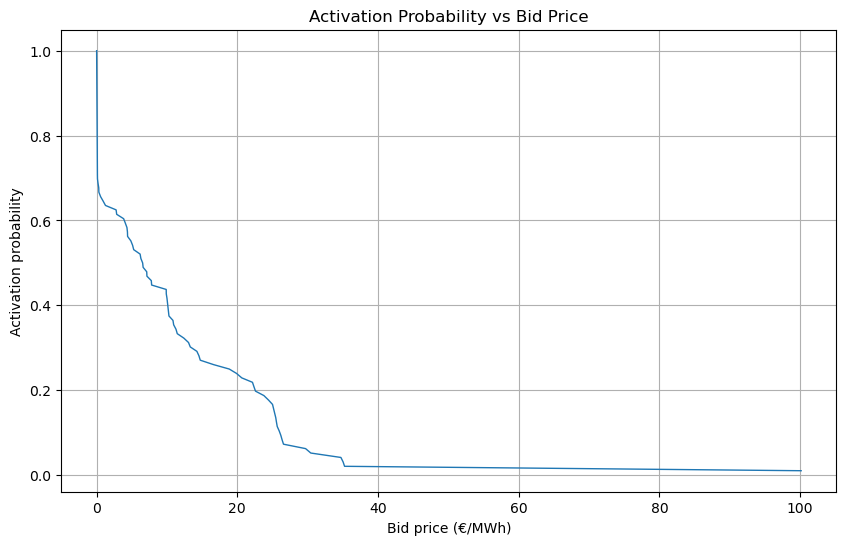

In [25]:
# Activation probability curve

import matplotlib.pyplot as plt

# sort values so the curve is clean
prob_plot = probability_table.sort_values("bid_price")

plt.figure(figsize=(10,6))

plt.plot(
    prob_plot["bid_price"],
    prob_plot["activation_probability"],
    linewidth=1
)

plt.xlabel("Bid price (€/MWh)")
plt.ylabel("Activation probability")
plt.title("Activation Probability vs Bid Price")

plt.grid(True)

plt.show()

# Step 5: Expected pay-as-cleared price term and compensation coefficient

It is calculated as : E [P_(max,k)  1(P_(max,k)≥p)] 

The resulting value has units of €/MWh



In [26]:
# STEP 5 — Expected activation price (EUR/MWh)

pmax_series = pmax_df["pmax"]
rows = []

for p in probability_table["bid_price"]:

    mask = pmax_series >= p
    
    expected_activation_price = (
        pmax_series.where(mask, 0.0)
        .fillna(0.0)
        .mean()
    )

    rows.append({
        "bid_price": p,
        "expected_price_term_eur_per_mwh": expected_activation_price
    })

expected_price_df = pd.DataFrame(rows)

print("\nEXPECTED ACTIVATION PRICE TABLE")
display(expected_price_df.head(20))


EXPECTED ACTIVATION PRICE TABLE


,bid_price,expected_price_term_eur_per_mwh
0,0.00,10.534479
1,0.11,10.534479
2,0.12,10.533333
3,0.20,10.532083
4,0.30,10.530000
5,0.32,10.526875
6,0.56,10.523542
7,0.92,10.517708
8,1.26,10.508125
9,2.77,10.495000


# Step 6: Expected EAM compensation

Under pay-as-cleared pricing, the expected activation compensation in interval k is

E[〖"Revenue" 〗_k∣p]=m_k Δt E[P_(max,k) 1(P_(max,k)≥p)].



In [27]:
# STEP 6 — Expected activated energy and expected EAM compensation


# parameters
delta_t = 0.25   # 15 minutes in hours
m_demo = 1.0     # demo volume in MW

step6_df = probability_table.merge(expected_price_df, on="bid_price", how="left")

step6_df["expected_activated_energy_mwh"] = (
    m_demo * delta_t * step6_df["activation_probability"]
)

# coefficient per MW
step6_df["expected_eam_compensation_coeff_eur_per_mw"] = (
    delta_t * step6_df["expected_price_term_eur_per_mwh"]
)

# total expected compensation for demo volume
step6_df["expected_eam_compensation_eur"] = (
    m_demo * step6_df["expected_eam_compensation_coeff_eur_per_mw"]
)

print("\nSTEP 6 RESULTS")
display(step6_df.head(20))


STEP 6 RESULTS


,bid_price,activation_probability,expected_price_term_eur_per_mwh,expected_activated_energy_mwh,expected_eam_compensation_coeff_eur_per_mw,expected_eam_compensation_eur
0,0.00,1.000000,10.534479,0.250000,2.633620,2.633620
1,0.11,0.708333,10.534479,0.177083,2.633620,2.633620
2,0.12,0.697917,10.533333,0.174479,2.633333,2.633333
3,0.20,0.687500,10.532083,0.171875,2.633021,2.633021
4,0.30,0.677083,10.530000,0.169271,2.632500,2.632500
5,0.32,0.666667,10.526875,0.166667,2.631719,2.631719
6,0.56,0.656250,10.523542,0.164062,2.630885,2.630885
7,0.92,0.645833,10.517708,0.161458,2.629427,2.629427
8,1.26,0.635417,10.508125,0.158854,2.627031,2.627031
9,2.77,0.625000,10.495000,0.156250,2.623750,2.623750


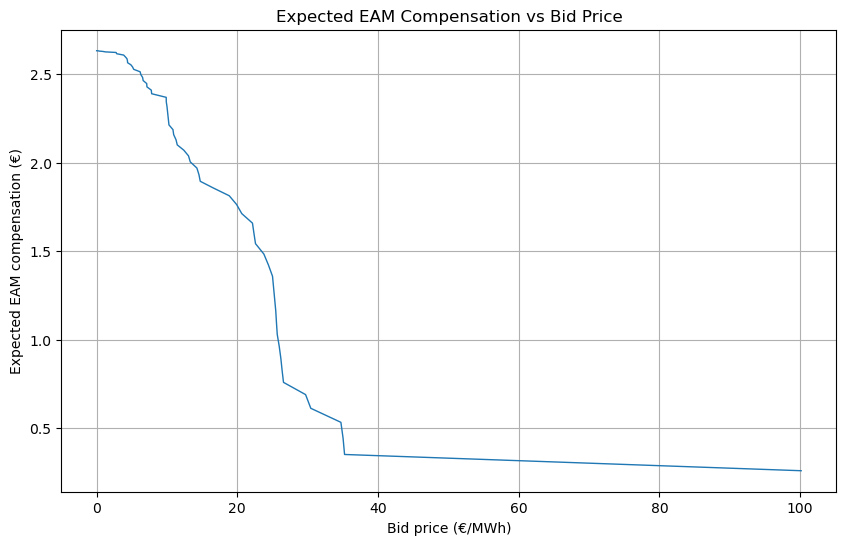

In [28]:
import matplotlib.pyplot as plt

comp_plot = step6_df.sort_values("bid_price")

plt.figure(figsize=(10,6))

plt.plot(
    comp_plot["bid_price"],
    comp_plot["expected_eam_compensation_eur"],
    linewidth=1
)

plt.xlabel("Bid price (€/MWh)")
plt.ylabel("Expected EAM compensation (€)")
plt.title("Expected EAM Compensation vs Bid Price")

plt.grid(True)

plt.show()

In [29]:
import numpy as np
import pandas as pd

def build_eam_statistics_per_day_period(pmax_df, bids_neg, delta_t=0.25):

    req_cols = {"Date", "period", "pmax"}
    missing = req_cols - set(pmax_df.columns)
    if missing:
        raise ValueError(f"pmax_df is missing required columns: {missing}")

    if {"DELIVERY_DATE", "period", "price"} - set(bids_neg.columns):
        raise ValueError("bids_neg must contain 'DELIVERY_DATE', 'period', 'price'")

    rows = []

    # Ensure same format
    pmax_df["Date"] = pd.to_datetime(pmax_df["Date"])
    bids_neg["DELIVERY_DATE"] = pd.to_datetime(bids_neg["DELIVERY_DATE"])

    # Loop over each (day, period)
    grouped = pmax_df.groupby(["Date", "period"])

    for (date, period), group in grouped:

        hist_pmax = pd.to_numeric(group["pmax"], errors="coerce")

        if hist_pmax.empty:
            continue

        # candidate prices ONLY from same day & period
        candidate_prices = np.sort(
            pd.to_numeric(
                bids_neg.loc[
                    (bids_neg["DELIVERY_DATE"] == date) &
                    (bids_neg["period"] == period),
                    "price"
                ],
                errors="coerce"
            ).dropna().unique()
        )

        if len(candidate_prices) == 0:
            continue

        for p in candidate_prices:

            indicator = (hist_pmax >= p).fillna(False).astype(float)

            activation_probability = indicator.mean()

            expected_price_term = (
                hist_pmax.where(hist_pmax >= p, 0.0)
                .fillna(0.0)
                .mean()
            )

            expected_eam_comp_coeff = delta_t * expected_price_term

            rows.append({
                "Date": date,
                "period": int(period),
                "bid_price": float(p),
                "n_hist_obs": int(len(hist_pmax)),
                "activation_probability": float(activation_probability),
                "expected_price_term_eur_per_mwh": float(expected_price_term),
                "expected_eam_compensation_coeff_eur_per_mw_per_interval": float(expected_eam_comp_coeff)
            })

    stats_table = pd.DataFrame(rows)

    if stats_table.empty:
        raise ValueError("stats_table is empty.")

    return stats_table

In [30]:
pmax_df.tail()

,Date,period,start_time,end_time,Activated_MW_neg,pmax
91,2025-10-05,92,22:45:00,23:00:00,17.946,0.56
92,2025-10-05,93,23:00:00,23:15:00,16.055,0.32
93,2025-10-05,94,23:15:00,23:30:00,3.644,0.12
94,2025-10-05,95,23:30:00,23:45:00,5.755,0.30
95,2025-10-05,96,23:45:00,00:00:00,148.580,5.11


In [31]:
len(pmax_df)

96

In [32]:
bids_neg.tail()

,DELIVERY_DATE,TYPE_OF_RESERVES,product,price,ENERGY_PRICE_PAYMENT_DIRECTION,OFFERED_CAPACITY_[MW],ALLOCATED_CAPACITY_[MW],COUNTRY,NOTE,period
74726,2025-10-05,aFRR,NEG_096,17.20,GRID_TO_PROVIDER,5,5,DE,NaN,96
74727,2025-10-05,aFRR,NEG_096,18.44,GRID_TO_PROVIDER,5,5,DE,NaN,96
74728,2025-10-05,aFRR,NEG_096,19.67,GRID_TO_PROVIDER,5,5,DE,NaN,96
74729,2025-10-05,aFRR,NEG_096,20.91,GRID_TO_PROVIDER,5,5,DE,NaN,96
74730,2025-10-05,aFRR,NEG_096,22.15,GRID_TO_PROVIDER,5,5,DE,NaN,96


In [33]:
len(bids_neg)

74731

In [34]:
eam_stats_table = build_eam_statistics_per_day_period(pmax_df, bids_neg, delta_t=0.25)

In [35]:
eam_stats_table.head()

,Date,period,bid_price,n_hist_obs,activation_probability,expected_price_term_eur_per_mwh,expected_eam_compensation_coeff_eur_per_mw_per_interval
0,2025-10-05,1,0.00,1,1.0,16.62,4.155
1,2025-10-05,1,1.15,1,1.0,16.62,4.155
2,2025-10-05,1,5.06,1,1.0,16.62,4.155
3,2025-10-05,1,5.58,1,1.0,16.62,4.155
4,2025-10-05,1,5.60,1,1.0,16.62,4.155


In [36]:
len(eam_stats_table)

53121

In [37]:
delta_t = 0.25
m_demo = 1.0

period_table = (
    eam_stats_table
    .sort_values(
        by=[
            "Date",
            "period",
            "expected_eam_compensation_coeff_eur_per_mw_per_interval",
            "bid_price"
        ],
        ascending=[True, True, False, False]
    )
    .groupby(["Date", "period"], as_index=False)
    .first()
)

period_table["expected_activated_energy_mwh"] = (
    m_demo * delta_t * period_table["activation_probability"]
)

period_table["expected_eam_compensation_eur"] = (
    m_demo * period_table["expected_eam_compensation_coeff_eur_per_mw_per_interval"]
)


In [38]:
print("\n=== 15 min BLOCK EAM INPUT TABLE ===")
display(period_table)


=== 15 min BLOCK EAM INPUT TABLE ===


,Date,period,bid_price,n_hist_obs,activation_probability,expected_price_term_eur_per_mwh,expected_eam_compensation_coeff_eur_per_mw_per_interval,expected_activated_energy_mwh,expected_eam_compensation_eur
0,2025-10-05,1,16.62,1,1.0,16.62,4.1550,0.25,4.1550
1,2025-10-05,2,29.70,1,1.0,29.70,7.4250,0.25,7.4250
2,2025-10-05,3,9.89,1,1.0,9.89,2.4725,0.25,2.4725
3,2025-10-05,4,100.14,1,1.0,100.14,25.0350,0.25,25.0350
4,2025-10-05,5,26.56,1,1.0,26.56,6.6400,0.25,6.6400
...,...,...,...,...,...,...,...,...,...
91,2025-10-05,92,0.56,1,1.0,0.56,0.1400,0.25,0.1400
92,2025-10-05,93,0.32,1,1.0,0.32,0.0800,0.25,0.0800
93,2025-10-05,94,0.12,1,1.0,0.12,0.0300,0.25,0.0300
94,2025-10-05,95,0.30,1,1.0,0.30,0.0750,0.25,0.0750


In [39]:
period_table.to_parquet("aFRR_EAM_optimal_bids_2025_10_05")